In [1]:

!unzip calDataset.zip -d /content/calDataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/calDataset/calDataset/train/minus/488.jpg  
  inflating: /content/calDataset/calDataset/train/minus/4890.jpg  
  inflating: /content/calDataset/calDataset/train/minus/4907.jpg  
  inflating: /content/calDataset/calDataset/train/minus/4949.jpg  
  inflating: /content/calDataset/calDataset/train/minus/4969.jpg  
  inflating: /content/calDataset/calDataset/train/minus/4999.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5012.jpg  
  inflating: /content/calDataset/calDataset/train/minus/503.jpg  
  inflating: /content/calDataset/calDataset/train/minus/504.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5050.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5053.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5074.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5082.jpg  
  inflating: /content/calDataset/calDataset/train/minus/5137.jpg  
  inflating: /

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [3]:
# 1. تحميل بيانات التدريب
train_dir = '/content/calDataset/calDataset/train'  # قم بتعديل المسار بناءً على مكان بيانات التدريب

# 2. تجهيز بيانات التدريب مع تقسيم جزء منها للتحقق (validation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  # تدوير الصور بحد أقصى 20 درجة
    width_shift_range=0.2,  # التحريك الأفقي
    height_shift_range=0.2,  # التحريك العمودي
    shear_range=0.2,  # التشويه
    zoom_range=0.2,  # التكبير والتصغير
    horizontal_flip=True,  # التقليب الأفقي
    fill_mode='nearest',  # لتعبئة المساحات الفارغة بعد التحولات
    validation_split=0.05  # تخصيص 5% من البيانات للتحقق (validation)
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # تغيير الحجم ليطابق المدخلات لـ VGG16
    batch_size=32,
    class_mode='categorical',  # وضع الفئات كـ categorical
    subset='training'  # تعيين هذا كجزء للتدريب
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # تغيير الحجم ليطابق المدخلات لـ VGG16
    batch_size=32,
    class_mode='categorical',  # وضع الفئات كـ categorical
    subset='validation'  # تعيين هذا كجزء للتحقق
)


Found 6967 images belonging to 14 classes.
Found 362 images belonging to 14 classes.


# New Section

In [4]:
# 3. تحميل VGG16 وتخصيصه للنموذج
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# تجميد الطبقات الأساسية من VGG16
base_model.trainable = False

# بناء النموذج باستخدام VGG16 كنموذج أساسي
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # طبقة Flatten لتحويل الأبعاد
    layers.Dense(500, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')  # عدد الفئات في بيانات التدريب
])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# 4. تجميع وتدريب النموذج
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# استخدام "EarlyStopping" لتقليل التدريب عند توقف التحسن
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,  # يمكن تعديل عدد الـ epochs حسب الحاجة
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[early_stopping]  # إضافة EarlyStopping لتحسين التدريب
)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


217/217 ━━━━━━━━━━━━━━━━━━━━ 114s 448ms/step - accuracy: 0.3421 - loss: 2.1711 - val_accuracy: 0.7784 - val_loss: 1.0311
Epoch 2/10
  1/217 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.7500 - loss: 1.0911

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


217/217 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7500 - loss: 1.0911 - val_accuracy: 0.5000 - val_loss: 1.3834
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 111s 395ms/step - accuracy: 0.7219 - loss: 0.9773 - val_accuracy: 0.8267 - val_loss: 0.6744
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - accuracy: 0.8750 - loss: 0.5000 - val_accuracy: 0.9000 - val_loss: 0.6175
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 397ms/step - accuracy: 0.8116 - loss: 0.6564 - val_accuracy: 0.8580 - val_loss: 0.5094
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8125 - loss: 0.9318 - val_accuracy: 0.7000 - val_loss: 0.8805
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 88s 395ms/step - accuracy: 0.8450 - loss: 0.5388 - val_accuracy: 0.8466 - val_loss: 0.4583
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.8438 - loss: 0.4523 - val_accuracy: 0.9000 - val_loss: 0.3684
Epoch 9/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 392ms/step - accuracy: 0.8625 - loss: 0.4600 - val_acc

In [6]:
# 6. تقييم النموذج على بيانات التحقق (validation)
test_loss, test_acc = model.evaluate(validation_generator)
print(f"Validation accuracy: {test_acc}")
print(f"Validation loss: {test_loss}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step - accuracy: 0.8624 - loss: 0.4701
Validation accuracy: 0.8756905794143677
Validation loss: 0.44381365180015564


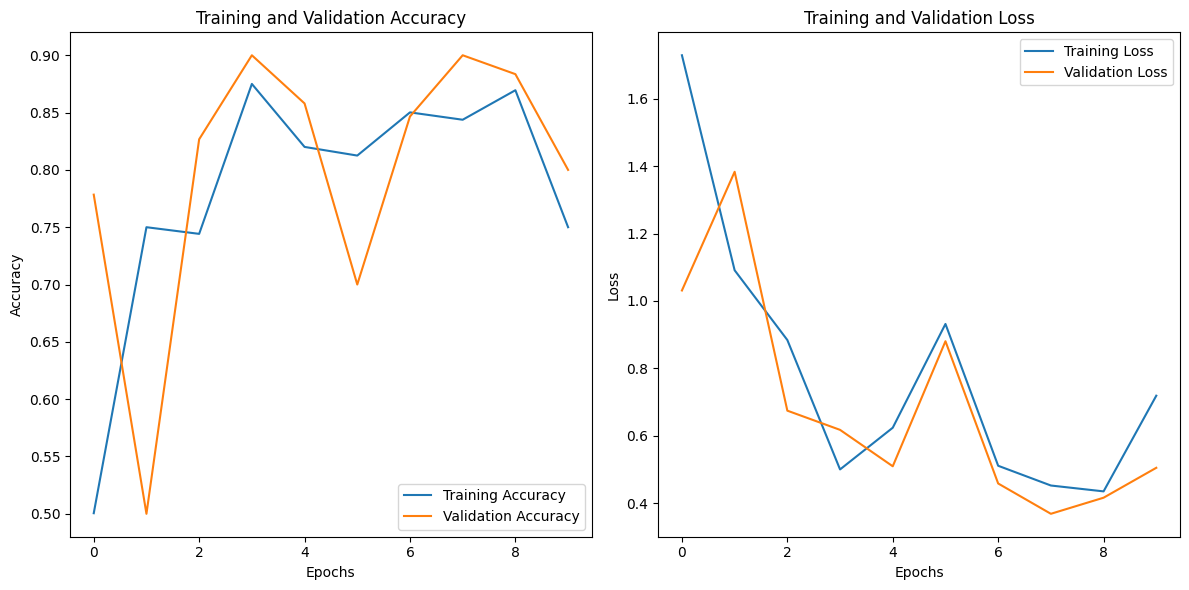

In [7]:
# 7. Visualizing the training process
# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [8]:
def strToSymbol(pred):

    if pred == "zero":
        return 0
    elif pred == "one":
        return 1
    elif pred == "two":
        return 2
    elif pred == "three":
        return 3
    elif pred == "four":
        return 4
    elif pred == "five":
        return 5
    elif pred == "six":
        return 6
    elif pred == "seven":
        return 7
    elif pred == "eight":
        return 8
    elif pred == "nine":
        return 9
    elif pred == "plus":
        return '+'
    elif pred == "minus":
        return '-'
    elif pred == "div":
        return '/'


    elif pred == "times":
        return '*'


def calculate(par1, sym, par2):
    if sym == "plus":
        return strToSymbol(par1) + strToSymbol(par2)
    elif sym == "minus":
        return strToSymbol(par1) - strToSymbol(par2)
    elif sym == "div":
        return strToSymbol(par1) / strToSymbol(par2)
    elif sym == "times":
        return strToSymbol(par1) * strToSymbol(par2)


Width :  706  , Height :  258


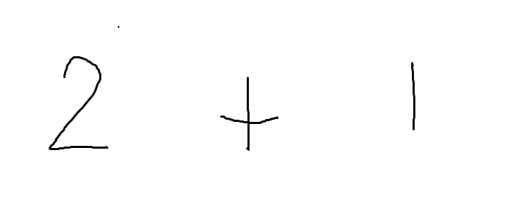

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


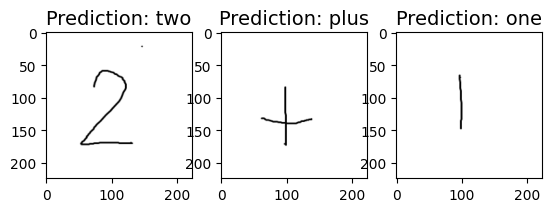

2 + 1  =  3


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
label_encoder.fit(list(train_generator.class_indices.keys()))  # Fit with class names
image = Image.open("/content/img5.png")
image=image.convert('RGB')
equation = []

width, height = image.size
print("Width : " , width, " , Height : ", height)
plt.imshow(image)
plt.axis('off')
plt.show()

fig, axs= plt.subplots(1,3)
div = int(width/3)

for i in range(0,3):
    left = i * div
    top = 0
    right = (i+1) * div
    bottom = height

    temp_img = image.crop((left, top, right, bottom))

    temp_img = temp_img.resize((224,224))
    img = np.array(temp_img)
    img = np.expand_dims(img, axis=0)
    img = img.astype('float32')
    img /= 255


    pred = model.predict(img)
    result = np.argsort(pred)
    result = result[0][::-1]

    final_label = label_encoder.inverse_transform(np.array(result))

    equation.append(final_label[0])

    axs[i].imshow(temp_img)
    axs[i].set_title(str("Prediction: " + final_label[0]), fontsize = 14)

plt.show()
print(strToSymbol(equation[0]), strToSymbol(equation[1]) , strToSymbol(equation[2]), " = ", calculate(equation[0], equation[1] , equation[2]))

In [11]:
# تحويل النموذج إلى TFLite
model.save('HRC.h5')

# تحويل النموذج إلى TFLite
import tensorflow as tf
# Use from_keras_model instead of from_keras_model_file
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# حفظ النموذج بتنسيق tflite
with open('HRC3.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpoxwobvd2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_19')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  133774143294800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774141493792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774142111088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774142103344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774142103520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774122521472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774142107392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774122526224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774122530448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133774122527280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1337741225